In [17]:
import os
import torch
import shutil
import zipfile
import json
import requests
import matplotlib.pyplot as plt

In [2]:
root = '/kaggle/working/tiny-net/tiny-imagenet-200'

In [3]:
torch.cuda.device_count()

2

In [4]:
!nvidia-smi

Fri Feb 27 09:20:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
url = 'http://cs231n.stanford.edu/tiny-imagenet-200.zip'
r = requests.get(url, timeout=10)
r.raise_for_status()

with open('tiny-net.zip', 'wb') as f:
  f.write(r.content)

In [6]:
zip_path = 'tiny-net.zip'
extraction_path = './tiny-net'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extraction_path)

In [7]:
os.listdir(os.path.join(os.path.join(extraction_path,'tiny-imagenet-200'), 'train'))[:10]

['n07875152',
 'n03599486',
 'n04023962',
 'n02085620',
 'n02395406',
 'n07920052',
 'n04560804',
 'n03637318',
 'n02843684',
 'n03404251']

In [8]:
class FormatFolder:
  def __init__(self, root, subdir):

    self.images = []
    self.labels = []

    self.dir = os.path.join(root, 'val')
    self.full_path = os.path.join(self.dir, subdir)
    self.extract()
    self.move_to_folder()

  def extract(self):
    with open(self.full_path) as f:
      for line in f:

        parts = line.strip().split('\t')
        self.images.append(parts[0])
        self.labels.append(parts[1])

  def move_to_folder(self):

    images_dir = os.path.join(self.dir, 'images')

    for img, label in zip(self.images, self.labels):

      cls_dir = os.path.join(self.dir, label)
      os.makedirs(cls_dir, exist_ok=True)

      source = os.path.join(images_dir, img)
      destination = os.path.join(cls_dir, img)

      if os.path.exists(source):
        shutil.move(source, destination)


In [9]:
FormatFolder(root, 'val_annotations.txt')
shutil.rmtree('/kaggle/working/tiny-net/tiny-imagenet-200/val/images', ignore_errors=True)

In [12]:
!python /kaggle/input/datasets/mrheavenly/vit-training-script-gpu/train.py

Rank 1 running on GPU Tesla T4
Rank 0 running on GPU Tesla T4
Epoch: [1/80]
	Train Loss: 5.07817 | Val Loss: 4.81002
	Train Acc: 2.15% | Val Acc: 4.21%
	Time: 184.03s (3.07 min)
--------------------------------------------------
Saved new best model
Epoch: [2/80]
	Train Loss: 4.86522 | Val Loss: 4.63351
	Train Acc: 3.76% | Val Acc: 6.26%
	Time: 189.36s (3.16 min)
--------------------------------------------------
Saved new best model
Epoch: [3/80]
	Train Loss: 4.76471 | Val Loss: 4.52095
	Train Acc: 4.88% | Val Acc: 7.65%
	Time: 190.09s (3.17 min)
--------------------------------------------------
Saved new best model
Epoch: [4/80]
	Train Loss: 4.69187 | Val Loss: 4.46462
	Train Acc: 5.71% | Val Acc: 8.18%
	Time: 190.24s (3.17 min)
--------------------------------------------------
Saved new best model
Epoch: [5/80]
	Train Loss: 4.63308 | Val Loss: 4.36680
	Train Acc: 6.43% | Val Acc: 9.44%
	Time: 190.47s (3.17 min)
--------------------------------------------------
Saved new best mode

In [15]:
with open('history.json', 'r') as f:
    history = json.load(f)

In [23]:
import os
import math
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn import functional as F
from torchvision.io import read_image
from torchvision import transforms as T
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP

# 1. Hyperparameters
size = 64
patch = 16
dropout = 0.3
n_layers = 12
num_workers = 4
batch_size = 128
max_iterations = 80
root = '/kaggle/working/tiny-net/tiny-imagenet-200'



In [24]:
class PatchEmbedding(nn.Module):
  def __init__(self, patch_size, d_model):
    super().__init__()

    self.conv = nn.Conv2d(in_channels=3, out_channels=d_model, kernel_size=patch_size, stride=patch_size)
    self.flatten = nn.Flatten(start_dim=2)

    self.cls = nn.Parameter(torch.randn(1, 1, d_model))
  def forward(self, x):

    B = x.shape[0]
    patches = self.conv(x)
    patches = self.flatten(patches)

    patches = patches.transpose(1,2)

    cls_tokens = self.cls.expand(B, -1, -1)
    patches = torch.concat((cls_tokens, patches), dim=1)

    return patches
class PositionalEncoding(nn.Module):
  def __init__(self, num_patches, d_model):
    super().__init__()

    pe = torch.zeros((num_patches+1, d_model))

    position = torch.arange(0,num_patches+1, dtype=torch.float).unsqueeze(1)

    div_term = torch.exp(
        -torch.arange(0, d_model, 2) * math.log(10000.0) / d_model
    )

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    pe = pe.unsqueeze(0)

    self.register_buffer('pe', pe)

  def forward(self, x):
    T = x.shape[1]

    return x + self.pe[:, :T]

class MHA(nn.Module):
  def __init__(self, d_model, n_heads):

    super().__init__()
    self.d_model = d_model
    self.n_heads = n_heads
    self.d_k = d_model // n_heads

    self.WQ = nn.Linear(d_model, d_model, bias=False)
    self.WK = nn.Linear(d_model, d_model, bias=False)
    self.WV = nn.Linear(d_model, d_model, bias=False)

    self.proj = nn.Linear(d_model, d_model, bias=False)
    self.dropout = nn.Dropout(dropout)

  def forward(self, x):
    B, T, _ = x.shape

    Q = self.WQ(x).view(B,T, self.n_heads, self.d_k).transpose(1,2)
    K = self.WK(x).view(B,T, self.n_heads, self.d_k).transpose(1,2)
    V = self.WV(x).view(B,T, self.n_heads, self.d_k).transpose(1,2)

    score = torch.matmul(Q, K.transpose(-2, -1)) * (self.d_k ** -0.5)
    attn = F.softmax(score, dim=-1)
    attn = self.dropout(attn)

    out = torch.matmul(attn, V)
    out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)

    return self.proj(out)
  
class Encoder(nn.Module):
  def __init__(self,d_model, n_heads):
    super().__init__()

    self.mha = MHA(d_model, n_heads)
    self.ln1 = nn.LayerNorm(d_model)
    self.ln2 = nn.LayerNorm(d_model)
    self.mlp = nn.Sequential(*[
        nn.Linear(d_model, d_model*4),
        nn.GELU(),
        nn.Linear(d_model*4, d_model),
        nn.Dropout(dropout),
    ])

  def forward(self, x):

    x = x + self.mha(self.ln1(x))
    x = x + self.mlp(self.ln2(x))

    return x
  
class ViT(nn.Module):
  def __init__(self, d_model, n_heads, num_classes):

    super().__init__()

    num_patches = (size // patch) ** 2

    self.patched_embd = PatchEmbedding(patch, d_model)
    self.pos_encd = PositionalEncoding(num_patches, d_model)

    self.encoders = nn.ModuleList([
        Encoder(d_model, n_heads) for _ in range(n_layers)
    ])

    self.ln = nn.LayerNorm(d_model)
    self.head = nn.Linear(d_model, num_classes)

  def forward(self, x):

    x = self.patched_embd(x)
    x = self.pos_encd(x)

    for encoder in self.encoders:
      x = encoder(x)

    cls_token = x[:, 0, :]

    out = self.ln(cls_token)
    out = self.head(out)

    return out

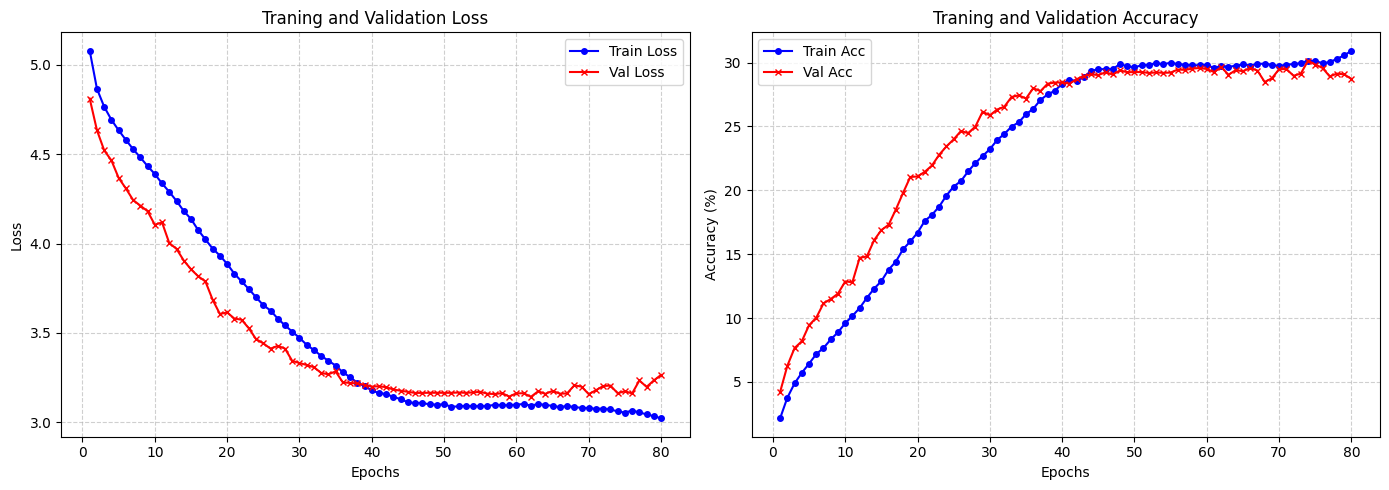

In [20]:
epochs_range = range(1, len(history['train_loss'])+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', marker='o', markersize=4)
ax1.plot(epochs_range, history['val_loss'], label='Val Loss', color='red', marker='x', markersize=4)
ax1.set_title("Traning and Validation Loss")
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

ax2.plot(epochs_range, history['train_acc'], label='Train Acc', color='blue', marker='o', markersize=4)
ax2.plot(epochs_range, history['val_acc'], label='Val Acc', color='red', marker='x', markersize=4)
ax2.set_title("Traning and Validation Accuracy")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
plt.savefig("Loss_and_Acc_plot.png")

plt.tight_layout()
plt.show()

In [28]:
class TinyImagenetDataset(Dataset):
  def __init__(self, root, transforms, split, sub_dir):

    self.root = root
    self.sub_dir = sub_dir

    self.transforms = transforms

    self.full_path = os.path.join(root, split)
    self.Set = tuple()
    self.flatten = []

    self.class_names = None
    self.cls_to_idx = None
    self.idx_to_cls = None



    self.find_sort()

    self.make_set()

    if self.flatten == []:
      self.flatten_set()
      self.len = len(self.flatten)

  def find_sort(self):

    if not self.class_names:
      self.class_names = sorted([d for d in os.listdir(self.full_path) if os.path.isdir(os.path.join(self.full_path, d))])

    if not self.cls_to_idx:
      self.cls_to_idx = {cls:idx for idx, cls in enumerate(self.class_names)}

    if not self.idx_to_cls:
      self.idx_to_cls = {idx:cls for idx, cls in enumerate(self.class_names)}


  def make_set(self):

    for name in self.class_names:
      pair = ((name, self.cls_to_idx[name]),)
      self.Set += pair

  def flatten_set(self):


    for t in self.Set:

      cls_dir = os.path.join(self.full_path, t[0])
      img_dir = os.path.join(cls_dir, self.sub_dir)

      for img in os.listdir(img_dir):
        pair = (os.path.join(img_dir, img), t[1])
        self.flatten.append(pair)


  def process_img(self,idx):

    t = self.flatten[idx]


    img_uint8 = read_image(t[0])
    img = img_uint8.float().div(255.0)
    if img.shape[0] == 1:
      img = img.repeat(3,1,1)

    label = torch.tensor(t[1], dtype=torch.long)

    return img, label

  def __len__(self):

    return self.len

  def __getitem__(self, idx):

    img, label = self.process_img(idx)

    if self.transforms:
      img = self.transforms(img)

    return img,label

In [ ]:
def predict_image(image_path, model_path="best_vit_ddp.pth", device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    val_transforms = T.Compose([
        T.Resize(64, interpolation=T.InterpolationMode.BILINEAR),
        T.CenterCrop(64),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_uint8 = read_image(image_path)
    img = img_uint8.float().div(255.0)
    
    if img.shape[0] == 1:  # Handle grayscale images
        img = img.repeat(3, 1, 1)
        
    img_tensor = val_transforms(img).unsqueeze(0).to(device)

    model = ViT(d_model=768, n_heads=12, num_classes=200).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    with torch.no_grad():
        output = model(img_tensor)
        probabilities = F.softmax(output, dim=1)
        confidence, predicted_class = torch.max(probabilities, 1)


    display_img = img.permute(1, 2, 0).cpu().numpy()
    
    plt.figure(figsize=(4, 4))
    plt.imshow(display_img)
    plt.title(f"Predicted Class Index: {predicted_class.item()}\nConfidence: {confidence.item()*100:.2f}%")
    plt.axis('off')
    plt.show()

    return predicted_class.item(), confidence.item()

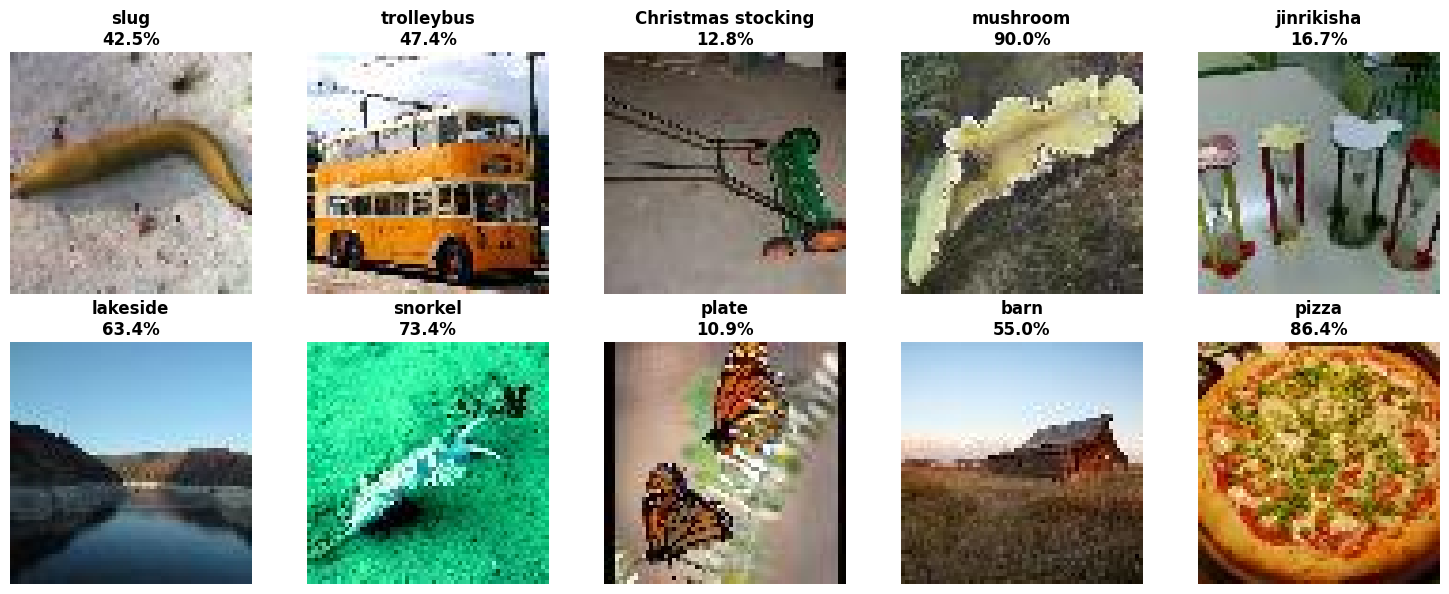

<Figure size 640x480 with 0 Axes>

In [26]:
import os
import glob
import torch
import torch.nn.functional as F
from torchvision.io import read_image
from torchvision import transforms as T
import matplotlib.pyplot as plt

def test_batch_inference(model_path="best_vit_ddp.pth", num_images=10):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    base_dir = '/kaggle/working/tiny-net/tiny-imagenet-200'
    test_dir = os.path.join(base_dir, 'test', 'images')
    train_dir = os.path.join(base_dir, 'train')
    words_file = os.path.join(base_dir, 'words.txt')
    

    class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    idx_to_wnid = {idx: cls for idx, cls in enumerate(class_names)}
    
    wnid_to_word = {}
    with open(words_file, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                wnid_to_word[parts[0]] = parts[1]
                
    model = ViT(d_model=768, n_heads=12, num_classes=200).to(device)
   
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    

    val_transforms = T.Compose([
        T.Resize(64, interpolation=T.InterpolationMode.BILINEAR),
        T.CenterCrop(64),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    

    test_images = glob.glob(os.path.join(test_dir, '*.JPEG'))[:num_images]
    
    batch_tensors = []
    display_images = []
    
    for img_path in test_images:
        img_uint8 = read_image(img_path)
        img = img_uint8.float().div(255.0)
        
        if img.shape[0] == 1: # Convert grayscale to RGB if necessary
            img = img.repeat(3, 1, 1)
            
        
        display_images.append(img.permute(1, 2, 0).numpy())
        
        batch_tensors.append(val_transforms(img))
        

    batch_tensor = torch.stack(batch_tensors).to(device)
    
    with torch.no_grad():
        outputs = model(batch_tensor)
        probs = F.softmax(outputs, dim=1)
        confidences, predictions = torch.max(probs, 1)
        
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i in range(num_images):
        pred_idx = predictions[i].item()
        conf = confidences[i].item()
        wnid = idx_to_wnid[pred_idx]
        
        word = wnid_to_word.get(wnid, "Unknown").split(',')[0]
        
        axes[i].imshow(display_images[i])
        axes[i].set_title(f"{word}\n{conf*100:.1f}%", fontsize=12, fontweight='bold')
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()
    plt.savefig('prediction_on_10_images.png')

test_batch_inference(num_images=10)

In [29]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms as T

def evaluate_accuracy(model_path="best_vit_ddp.pth", batch_size=128):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    root = '/kaggle/working/tiny-net/tiny-imagenet-200'
    val_transforms = T.Compose([
        T.Resize(64, interpolation=T.InterpolationMode.BILINEAR),
        T.CenterCrop(64),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_dataset = TinyImagenetDataset(root, val_transforms, 'val', '')
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    model = ViT(d_model=768, n_heads=12, num_classes=200).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    correct_top1 = 0
    correct_top5 = 0
    total = 0

    print("Running evaluation on the 10,000 validation images... This might take a minute.")

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            
            _, pred_top1 = outputs.max(1)
            correct_top1 += pred_top1.eq(labels).sum().item()
            
            _, pred_top5 = outputs.topk(5, 1, True, True)
            labels_resized = labels.view(-1, 1).expand_as(pred_top5)
            correct_top5 += pred_top5.eq(labels_resized).sum().item()
            
            total += labels.size(0)

    top1_acc = 100. * correct_top1 / total
    top5_acc = 100. * correct_top5 / total

    print("-" * 40)
    print("🏆 FINAL VALIDATION ACCURACY REPORT 🏆")
    print("-" * 40)
    print(f"Total Images Evaluated : {total}")
    print(f"Top-1 Accuracy         : {top1_acc:.2f}%")
    print(f"Top-5 Accuracy         : {top5_acc:.2f}%")
    print("-" * 40)
    
    return top1_acc, top5_acc

evaluate_accuracy()

Running evaluation on the 10,000 validation images... This might take a minute.
----------------------------------------
🏆 FINAL VALIDATION ACCURACY REPORT 🏆
----------------------------------------
Total Images Evaluated : 10000
Top-1 Accuracy         : 30.15%
Top-5 Accuracy         : 55.22%
----------------------------------------


(30.15, 55.22)